# **Graph Traversal**

*Graph Traversal* merupakan proses mengunjungi setiap *vertex/node* . *Graph Traversal* digunakan
untuk mencari jalur dalam suatu *graph* dari titik asal ke titik tujuan, mencari jalur terpendek antara
dua *node/vertex*, menemukan semua jalur yang bisa dilalui dari titik asal ke titik tujuan.


Berikut adalah contoh graph untuk proses graph traversal.

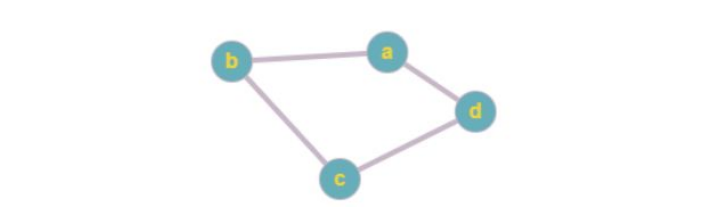

**Gambar 1. Graph**

Struktur data graph tersebut dengan menggunakan dictionary adalah sebagai berikut:<br>
graph = {'a':['b','d'], 'b':['a','d'], 'c':['d'],'d':['a','b','c']}

Dictionary tersebut berisi semua node/simpul serta list tetangganya, dimana setiap key suatu
simpul akan berkorespondensi dengan semua tetangganya yang terhubung dengan simpul key
tersebut. Berikut ini adalah implementasi mencari jalur dari simpul asal ke simpul tujuan, jika ada
jalur maka nilai yang dikembalikan adalah list path jika tidak ada jalur maka nilai yang
dikembalikan none. Algoritma yang digunakan adalah backtracking, yaitu mencoba setiap
kemungkinan secara bergantian sampai menemukan solusi.


### Code

Berikut adalah implementasi *graph traversal*

In [1]:
graph = {'a': ['b', 'd'],'b': ['a', 'd'], 'c': ['d'], 'd': ['a', 'b', 'c']}
def find_path(graph, start, end, path=[]):
    path = path + [start]
    for node in graph[start]:
        if not node in path:
            newpath = find_path(graph, node, end, path)
            if newpath:
                return newpath
    if start == end:
        return path
    if not start in graph:
        return None
    return None

    
print(find_path(graph,'a','d'))

['a', 'b', 'd']


### Latihan

Buatlah program untuk mendapatkan path untuk jalur terpendek dan terpanjang dari sebuah
graph. (jalur terpendek / terpanjang HARUS lebih dari 1 dan ditampilkan semua). Semisalkan ada
graph seperti berikut ini 

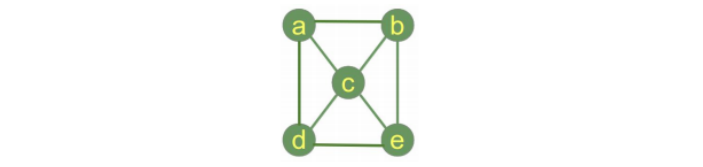

**Gambar 2. Graph**

In [2]:
# Fungsi untuk mencari SEMUA kemungkinan jalur
def cari_semua_jalur(graph, start, end, path=[]):
    path = path + [start]
    if start == end:
        return [path]
    if start not in graph:
        return []
    
    paths = []
    for node in graph[start]:
        if node not in path:
            newpaths = cari_semua_jalur(graph, node, end, path)
            for newpath in newpaths:
                paths.append(newpath)
    return paths

# Fungsi untuk memfilter dan menampilkan jalur terpendek dan terpanjang
def jalur_terpendek_terpanjang(graph, start, end):
    semua_jalur = cari_semua_jalur(graph, start, end)
    
    # Syarat dari soal: "Jalur harus lebih dari 1".
    # Asumsi: Panjang > 1 edge (berarti jumlah node dalam path harus > 2)
    jalur_valid = [p for p in semua_jalur if len(p) > 2]
    
    if not jalur_valid:
        print("Tidak ada jalur yang memenuhi syarat (> 1 edge).")
        return
    
    # Menghitung ukuran (jumlah node) pada setiap jalur valid
    panjang_jalur = [len(p) for p in jalur_valid]
    
    min_len = min(panjang_jalur)
    max_len = max(panjang_jalur)
    
    # Memfilter jalur yang sesuai dengan panjang min dan max
    jalur_terpendek = [p for p in jalur_valid if len(p) == min_len]
    jalur_terpanjang = [p for p in jalur_valid if len(p) == max_len]
    
    print(f"=== Menampilkan Jalur dari '{start}' ke '{end}' ===")
    
    print(f"\nJALUR TERPENDEK (Melewati {min_len-1} edge):")
    for j in jalur_terpendek:
        print(" -> ".join(j))
        
    print(f"\nJALUR TERPANJANG (Melewati {max_len-1} edge):")
    for j in jalur_terpanjang:
        print(" -> ".join(j))

# Definisi graph dari Latihan 2 (Gambar 2)
graph_latihan = {
    'a': ['b', 'c', 'd'],
    'b': ['a', 'c', 'e'],
    'c': ['a', 'b', 'd', 'e'],
    'd': ['a', 'c', 'e'],
    'e': ['b', 'c', 'd']
}

# Mengeksekusi Latihan untuk mencari jalur dari titik 'a' ke 'e'
jalur_terpendek_terpanjang(graph_latihan, 'a', 'e')

=== Menampilkan Jalur dari 'a' ke 'e' ===

JALUR TERPENDEK (Melewati 2 edge):
a -> b -> e
a -> c -> e
a -> d -> e

JALUR TERPANJANG (Melewati 4 edge):
a -> b -> c -> d -> e
a -> d -> c -> b -> e
